In [248]:
import pytesseract
import cv2
import numpy as np
import os
import easyocr
import re
import json
from matplotlib import pyplot as plt
from PIL import Image
from skimage.filters import threshold_otsu
import imutils

In [240]:
def display(img, title="Image"):
    plt.figure(figsize=(5, 5))
    plt.imshow(img,cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

In [241]:
img_path="pancard/2.png"
img = cv2.imread(img_path)

In [242]:
def deskew(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 100, minLineLength=100, maxLineGap=10)
    if lines is not None:
        angles = [np.arctan2(y2 - y1, x2 - x1) for [[x1, y1, x2, y2]] in lines]
        median_angle = np.median(angles)
        angle_deg = np.degrees(median_angle)
        if abs(angle_deg) > 1:
            (h, w) = image.shape[:2]
            M = cv2.getRotationMatrix2D((w // 2, h // 2), angle_deg, 1.0)
            image = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
    return image

In [243]:
def preprocess(image):
    gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
    return gray

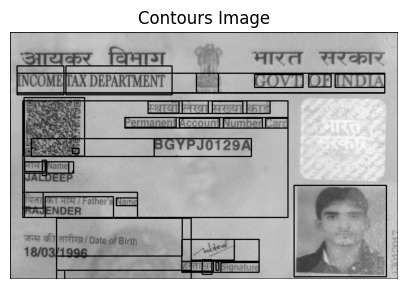

In [244]:
import pytesseract
from pytesseract import Output
def detect_text(image):
    d = pytesseract.image_to_data(image, output_type=Output.DICT)
    boxes=image.copy()
    for x, y, w, h in zip(d['left'], d['top'], d['width'], d['height']):
        cnts=cv2.rectangle(boxes, (x, y), (x + w, y + h), (0, 0, 255), 2)
    return cnts   
deskewed=deskew(img)
preprocessed_image=preprocess(deskewed)    
contours_image=detect_text(preprocessed_image)
display(contours_image,"Contours Image")

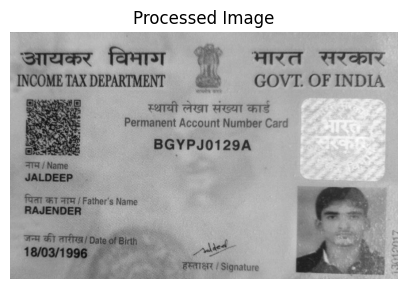

Pytesseract Output:
INCOMBITAX DEMARTMEND §=[€23) GOVT. OF INDIA
SES] rorett ere Gea ATS
we Permanent Account Number Card
Sasha ile
Nahe BGYPJ0129A
a / Name
jJALDEEP =
[at at ATH / Fathers Name [=
IRAJENDER ¢
ma ay arena) Date of Bicth - J —
BPATAR|/ Signature = ae |


In [245]:
def pytesseract_ocr(image):
    text = pytesseract.image_to_string(image,lang='eng' ,config='--psm 6 --oem 3').strip()
    return text
deskewed=deskew(img)
processed_image = preprocess(deskewed)
display(processed_image, "Processed Image")
contours_image=text_contours(preprocessed_image)    
text = pytesseract_ocr(contours_image)
print("Pytesseract Output:")    
print(text)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


(626, 1024, 3)
Extracted Text from Image (Confidence > 0.3):
Text: INCOME TAX DEPARTMENT, Confidence: 0.79
Text: GOVT OF INDIA, Confidence: 0.93
Text: Permanent Account Number Card, Confidence: 0.82
Text: FNMPR4593H, Confidence: 1.00
Text: Name, Confidence: 1.00
Text: PITHANI TARUN RoHIT SAI, Confidence: 0.73
Text: Father's Name, Confidence: 0.80
Text: PITHANI MURALIKRISHNA, Confidence: 0.99
Text: 06032023, Confidence: 1.00
Text: Date of Birth, Confidence: 0.96
Text: 28/06/2004, Confidence: 0.85
Text: €e / Signature, Confidence: 0.30


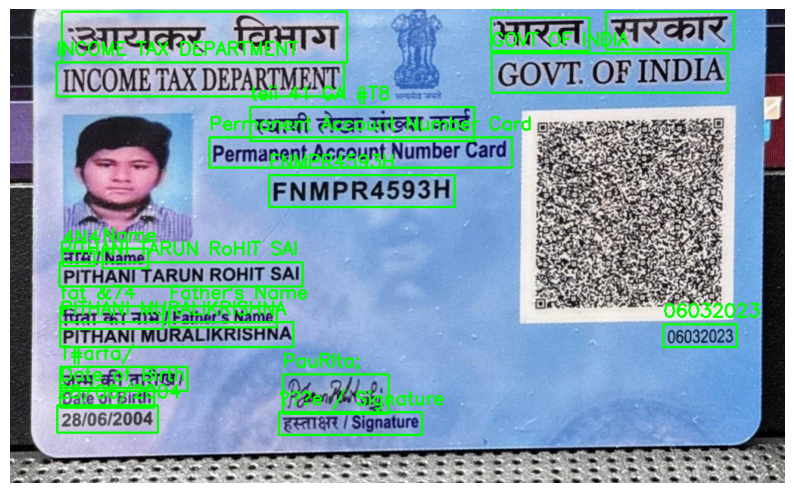

In [ ]:
import easyocr
import cv2
import matplotlib.pyplot as plt

# Initialize the EasyOCR reader
reader = easyocr.Reader(['en'])  # 'en' for English, adjust as needed

# Load your image using OpenCV
image_path = 'pancard/15.jpg'  # Replace with your image path
image = cv2.imread(image_path)
image = imutils.resize(image , height = 600)
# Perform text detection
results = reader.readtext(image)

# Draw bounding boxes and extract text with confidence > 0.3
print("Extracted Text from Image (Confidence > 0.3):")
for (bbox, text, prob) in results:
    # Extract the bounding box coordinates
    (top_left, top_right, bottom_right, bottom_left) = bbox
    top_left = (int(top_left[0]), int(top_left[1]))
    bottom_right = (int(bottom_right[0]), int(bottom_right[1]))

    # Draw rectangle around the text (for all detections)
    cv2.rectangle(image, top_left, bottom_right, (0, 255, 0), 2)
    
    # Optionally, add the text above the box
    cv2.putText(image, text, (top_left[0], top_left[1] - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
    
    # Print the extracted text only if confidence > 0.3
    if prob > 0.3:
        print(f"Text: {text}, Confidence: {prob:.2f}")

# Convert BGR to RGB for displaying with matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image with bounding boxes
plt.figure(figsize=(10, 10))
plt.imshow(image_rgb)
plt.axis('off')
plt.show()

# Optionally save the output image
#cv2.imwrite('output_image_with_boxes.jpg', image)